In [2]:
import sys
import os

# Adiciona o diretório raiz do projeto ao sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_extract.ETL import ELT
from config import settings
import pandas as pd
import matplotlib.pyplot as plt

# Leitura de Dados

In [6]:
dtype = {
    'inputUrl': 'str',
    'id': 'str',  # IDs são melhor tratados como texto
    'username': 'str',
    'url': 'str',
    'fullName': 'str',
    'biography': 'str',
    'externalUrls': 'str', # Provavelmente JSON, ler como texto primeiro
    'externalUrl': 'str',
    'externalUrlShimmed': 'str',
    'followersCount': 'int32',  # int32 economiza memória
    'followsCount': 'int32',
    'hasChannel': 'bool',
    'highlightReelCount': 'int32',
    'isBusinessAccount': 'bool',
    'joinedRecently': 'bool',
    'businessCategoryName': 'category',  # 'category' é ideal para textos repetidos
    'private': 'bool',
    'verified': 'bool',
    'profilePicUrl': 'str',
    'profilePicUrlHD': 'str',
    'igtvVideoCount': 'int32',
    'relatedProfiles': 'str', # Provavelmente JSON, ler como texto primeiro
    'latestIgtvVideos': 'str',
    'latestPosts': 'str',
    'postsCount': 'int32',
    'fbid': 'str',  # IDs são melhor tratados como texto
    'businessAddress': 'str'
}
df_profiles = pd.read_excel(settings.ALL_XLSX, sheet_name="profiles", dtype=dtype).drop(['highlightReelCount', 'igtvVideoCount', 'latestPosts', 'latestIgtvVideos', 'relatedProfiles'], axis=1)
df_profiles['inputUrl'] = df_profiles['inputUrl'].str[:-1]

In [7]:
dtype = {
    'inputUrl': 'object',
    'id': 'str',
    'type': 'object',
    'shortCode': 'object',
    'caption': 'object',
    'hashtags': 'object',
    'mentions': 'object',
    'url': 'object',
    'commentsCount': 'int64',
    'firstComment': 'object',
    'latestComments': 'object',
    'dimensionsHeight': 'str',
    'dimensionsWidth': 'str',
    'displayUrl': 'object',
    'images': 'object',
    'videoUrl': 'object',
    'alt': 'float64',
    'likesCount': 'int64',
    'videoViewCount': 'int64',
    'videoPlayCount': 'int64',
    'timestamp': 'object',
    'childPosts': 'object',
    'ownerFullName': 'object',
    'ownerUsername': 'object',
    'ownerId': 'str',
    'productType': 'object',
    'videoDuration': 'float64',
    'isSponsored': 'bool',
    'musicInfo': 'object',
    'isCommentsDisabled': 'bool',
    'taggedUsers': 'object',
    'coauthorProducers': 'object',
    'locationName': 'object',
    'locationId': 'str',
    'isPinned': 'float64',
    'data_hora': 'datetime64[ns]',
    'Tipo': 'object'
}
df_reels = pd.read_excel(settings.ALL_XLSX, sheet_name="reels", dtype=dtype).drop(['firstComment', 'latestComments', 'videoUrl', 'alt', 
                                                                                    'timestamp', 'childPosts', 'productType', 'taggedUsers', 
                                                                                    'type', 'hashtags', 'displayUrl', 'dimensionsHeight', 'dimensionsWidth',
                                                                                    'images', 'Tipo'], axis=1)
df_reels['isPinned'] = df_reels['isPinned'].astype(bool)

In [8]:
dtype = {
    # --- Identificadores e Texto (Object/String) ---
    'inputUrl': 'object',
    'id_reel': 'str',         # IDs são melhores como 'object' (string) para evitar overflow
    'type': 'object',
    'shortCode': 'object',
    'caption': 'object',
    'url': 'object',
    'firstComment': 'object',
    'displayUrl': 'object',
    'videoUrl': 'object',
    'alt': 'object',
    'ownerFullName': 'object',
    'ownerUsername_reel': 'object',
    'ownerId': 'object',         # ID
    'productType': 'object',
    'locationName': 'object',
    'locationId': 'object',      # ID
    'Width X Height': 'object',  # Ex: "1080x1920"
    'Tipo': 'object',
    'id_comment': 'object',      # ID
    'text': 'object',
    'ownerUsername_comment': 'object',
    'ownerProfilePicUrl': 'object',
    'owner.id': 'object',        # ID
    'owner.profile_pic_url': 'object',
    'owner.username': 'object',
    'sentiment_label': 'object', # Categórico (ex: 'positive')
    'text clean': 'object',
    'text_demojized': 'object',
    'Name': 'object',            # Nomes de Tópicos
    'Representation': 'object',  # Provavelmente lista de palavras como string
    'Representative_Docs': 'object', # Provavelmente lista de docs como string
    'Top_n_words': 'object',     # Provavelmente lista de palavras como string

    # --- Contagens (Integer) ---
    'commentsCount': 'int64',
    'dimensionsHeight': 'int64',
    'dimensionsWidth': 'int64',
    'likesCount_reel': 'int64',
    'videoViewCount': 'int64',
    'videoPlayCount': 'int64',
    'Total de Engajamento': 'int64',
    'repliesCount': 'int64',
    'likesCount_comment': 'int64',
    'comprimento texto': 'int64',
    'Topic': 'int64',            # IDs de Tópicos (ex: -1, 0, 1)

    # --- Números Decimais (Float) ---
    'videoDuration': 'float64',
    'sentiment_score': 'float64',
    'Probability': 'float64',

    # --- Booleanos (Flags) ---
    'isSponsored': 'bool',
    'isCommentsDisabled': 'bool',
    'isPinned': 'object',
    'owner.is_verified': 'bool',
    'Representative_document': 'bool',

    # --- Datas e Horas ---
    'timestamp_reel': 'object',
    'data_hora': 'object',
    'timestamp_comment': 'object'
}
df_comments = pd.read_excel(settings.ALL_XLSX, sheet_name="reels_latestComments", dtype=dtype)

# Análise Descritiva

In [9]:
df_reels.groupby('Clusters (AutoClusterHPO)').describe().T.reset_index().to_excel(
    'stats.xlsx',
    index=False
)

# Vizualizações

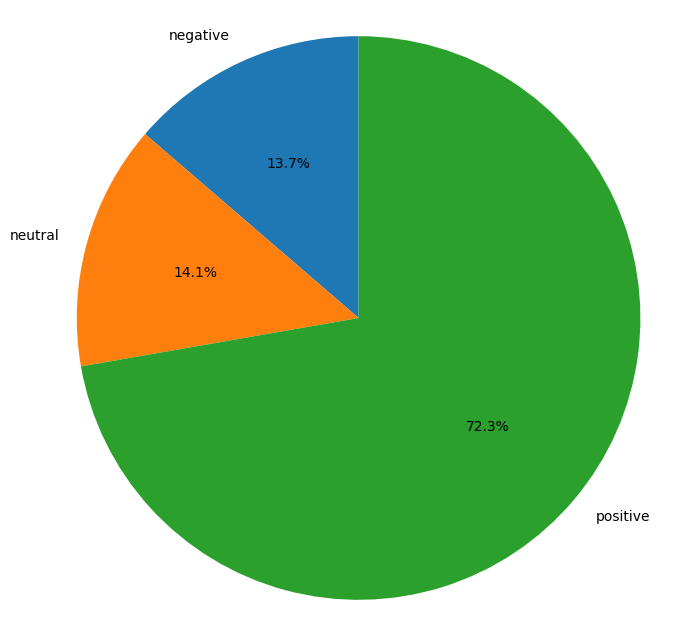

In [9]:
df_join = pd.merge(
    df_comments, 
    df_reels[['Clusters (AutoClusterHPO)', 'id']], 
    how='left', 
    left_on='id_reel',
    right_on='id'
)

# 1. Preparar os dados (Seu código original, está correto)
df_clusters = df_join[df_join['Clusters (AutoClusterHPO)'] == 0].groupby('sentiment_label').size().reset_index(name='Count')

# 2. Criar o gráfico
plt.figure(figsize=(8, 8))

# 3. CORREÇÃO:
#    - O primeiro argumento deve ser a coluna com os números (df_clusters['Count'])
#    - O argumento 'labels' deve ser a coluna com os nomes (df_clusters['sentiment_label'])
plt.pie(
    df_clusters['Count'],             # Os dados (valores numéricos)
    labels=df_clusters['sentiment_label'], # Os rótulos (nomes das fatias)
    autopct='%1.1f%%',            # Formato das porcentagens
    startangle=90
)

plt.axis('equal')  # Garante que o gráfico seja um círculo

#plt.savefig('grafico_sentimentos_cluster1.png')


# 4. Mostrar o gráfico
plt.show()

In [13]:
df_comments = pd.merge(df_comments, df_profiles[['inputUrl', 'fullName']], on='inputUrl', how='left')

df_govs_sentiment = df_comments.groupby(['sentiment_label', 'fullName']).size().reset_index(name='Count').pivot(index='fullName', columns='sentiment_label', values='Count').reset_index()

df_govs_sentiment['Qtd Comentários'] = df_govs_sentiment['negative'] + df_govs_sentiment['positive'] + df_govs_sentiment['neutral']

df_govs_sentiment['% positive'] = (df_govs_sentiment['positive'] / df_govs_sentiment['Qtd Comentários']) * 100

df_govs_sentiment['% positive'] = df_govs_sentiment['% positive'].round(2)

df_govs_sentiment['% negative'] = (df_govs_sentiment['negative'] / df_govs_sentiment['Qtd Comentários']) * 100

df_govs_sentiment['% negative'] = df_govs_sentiment['% negative'].round(2)

df_govs_sentiment['% neutral'] = (df_govs_sentiment['neutral'] / df_govs_sentiment['Qtd Comentários']) * 100

df_govs_sentiment['% neutral'] = df_govs_sentiment['% neutral'].round(2)

df_govs_sentiment.columns

Index(['fullName', 'negative', 'neutral', 'positive', 'Qtd Comentários',
       '% positive', '% negative', '% neutral'],
      dtype='object', name='sentiment_label')

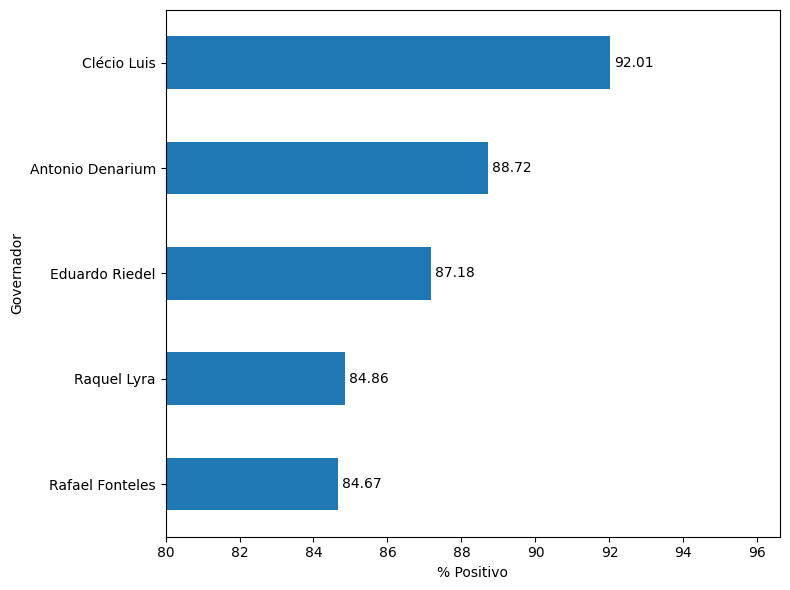

In [14]:
df_plot = df_govs_sentiment[['fullName', '% positive']].set_index('fullName').sort_values(by='% positive', ascending=False).head(5)

# Criar o gráfico de barras horizontal (barh)
ax = df_plot.plot(kind='barh', figsize=(8, 6), legend=False)

# Adicionar título e rótulos
ax.set_xlabel('% Positivo')
ax.set_ylabel('Governador')

ax.set_xlim(left=80)

# Inverter o eixo Y para que o maior valor (Clécio Luis) fique no topo
ax.invert_yaxis()

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.savefig('top_5_governadores_positivo.png')

# Exibir o gráfico
plt.tight_layout() # Ajusta o layout para não cortar os nomes
plt.show()

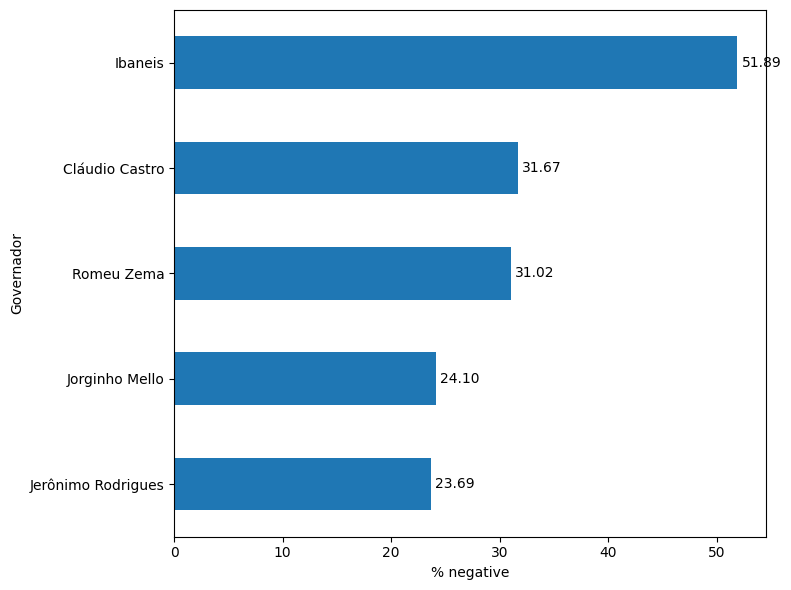

In [15]:
df_plot = df_govs_sentiment[['fullName', '% negative']].set_index('fullName').sort_values(by='% negative', ascending=False).head(5)

# Criar o gráfico de barras horizontal (barh)
ax = df_plot.plot(kind='barh', figsize=(8, 6), legend=False)

# Adicionar título e rótulos
ax.set_xlabel('% negative')
ax.set_ylabel('Governador')

# Inverter o eixo Y para que o maior valor (Clécio Luis) fique no topo
ax.invert_yaxis()

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.savefig('top_5_governadores_negativo.png')

# Exibir o gráfico
plt.tight_layout() # Ajusta o layout para não cortar os nomes
plt.show()